In [1]:
from mv_functions import *

## TASK 1

In [2]:
with open("/Users/saptarshimallikthakur/Downloads/data.json", "r") as f:
    data = json.load(f)


K = data['camera_intrinsics']['K']
pts_3d = data["cube_3d_points"]['points']

print("--- Camera 2 Pose Estimation ---")
R2, t2 = estimate_pose(data['camera2']['observations'], pts_3d, K)
print("Rotation Matrix (R):\n", np.round(R2, 4))
print("Translation (t):    ", np.round(t2, 4))

print("\n--- Camera 3 Pose Estimation ---")
R3, t3 = estimate_pose(data["camera3"]['observations'], pts_3d, K)
print("Rotation Matrix (R):\n", np.round(R3, 4))
print("Translation (t):    ", np.round(t3, 4))

--- Camera 2 Pose Estimation ---
Rotation Matrix (R):
 [[ 0.9771 -0.0372 -0.2093]
 [ 0.026   0.9981 -0.0559]
 [ 0.211   0.0492  0.9763]]
Translation (t):     [ 1.0987 -0.2047  4.9067]

--- Camera 3 Pose Estimation ---
Rotation Matrix (R):
 [[ 0.9646  0.0151  0.2632]
 [-0.0314  0.9978  0.0579]
 [-0.2617 -0.0641  0.963 ]]
Translation (t):     [-0.9978  0.3945  5.1723]


## TASK 2

In [3]:
K = np.array(K)

P1 = K @ np.hstack((np.eye(3), np.array([[0], [0], [5]])))
P2 = K @ np.hstack((R2, t2.reshape(3,1)))
P3 = K @ np.hstack((R3, t3.reshape(3,1)))

P_matrices = [P1, P2, P3]
gt_3d_points = np.array(pts_3d)

obs1 = data['camera1']['observations']
cam1_obs = [
    [o["u"], o["v"], o["confidence"]]
    for o in obs1
]

obs2 = data['camera2']['observations']
cam2_obs = [
    [o["u"], o["v"], o["confidence"]]
    for o in obs2
]

obs3 = data['camera3']['observations']
cam3_obs = [
    [o["u"], o["v"], o["confidence"]]
    for o in obs3
]


# Format: {point_index: [(cam_idx, u, v, confidence), ...]}
obs_by_point = {i: [] for i in range(8)}

for i in range(8):
    obs_by_point[i].append((0, cam1_obs[i][0], cam1_obs[i][1], cam1_obs[i][2]))
    if cam2_obs[i][0] is not None: obs_by_point[i].append((1, cam2_obs[i][0], cam2_obs[i][1], cam2_obs[i][2]))
    if cam3_obs[i][0] is not None: obs_by_point[i].append((2, cam3_obs[i][0], cam3_obs[i][1], cam3_obs[i][2]))

obs_by_point

{0: [(0, 232.1045, 150.8346, 0.8836),
  (1, 457.4013, 109.5989, 0.9909),
  (2, 53.6942, 221.3397, 0.9589)],
 1: [(0, 410.1843, 154.1572, 0.7418),
  (1, 622.4774, 122.9191, 0.9325),
  (2, 202.9677, 212.7159, 0.887)],
 2: [(0, 408.4206, 328.4206, 0.7876),
  (1, 614.2959, 298.4559, 0.9818),
  (2, 208.3595, 392.6788, 0.7993)],
 3: [(0, 234.2695, 330.4238, 0.8099),
  (1, 448.5113, 298.9932, 0.9684),
  (2, 55.2789, 382.7359, 0.7191)],
 4: [(0, 246.3338, 168.3578, 0.8368), (2, 133.0689, 231.6484, 0.7933)],
 5: [(0, 391.8004, 166.3413, 0.9356), (1, 540.4844, 135.7055, 0.8794)],
 6: [(0, 393.2112, 308.9007, 0.7599),
  (1, 532.0137, 279.7124, 0.9766),
  (2, 268.0219, 374.1943, 0.7976)],
 7: [(0, 243.8229, 311.6027, 0.8543), (2, 130.6035, 370.0109, 0.9189)]}

In [4]:
dlt_points = []
optimal_points = []
errors_dlt = []
errors_optimal = []

print("--- 3D Triangulation Results ---")
print(f"{'Pt':<3} | {'Views':<5} | {'GT':<20} | {'DLT':<20} | {'OPT':<20} | {'DLT Err(mm)':<12} | {'OPT Err(mm)':<12}")
print("-" * 110)

for i in range(8):
    obs = obs_by_point[i]
    gt = gt_3d_points[i]
    
    # 1. DLT Triangulation
    X_dlt = triangulate_dlt(obs, P_matrices)
    dlt_points.append(X_dlt)
    
    # 2. Optimal Triangulation
    X_opt = triangulate_optimal(X_dlt, obs, P_matrices)
    optimal_points.append(X_opt)
    
    # Calculate Euclidean distance in mm (cube is 1m, so multiply by 1000)
    err_dlt = np.linalg.norm(X_dlt - gt) * 1000
    err_opt = np.linalg.norm(X_opt - gt) * 1000
    
    errors_dlt.append(err_dlt)
    errors_optimal.append(err_opt)
    
    print(
        f"{i:<3} | {len(obs):<5} | "
        f"{np.round(gt,2).tolist()!s:<20} | "
        f"{np.round(X_dlt,2).tolist()!s:<20} | "
        f"{np.round(X_opt,2).tolist()!s:<20} | "
        f"{err_dlt:<10.2f} | {err_opt:<10.2f}"
    )

worst_pt = np.argmax(errors_optimal)
print(f"\nHighest Error Point: Point {worst_pt} ({errors_optimal[worst_pt]:.2f} mm)")

--- 3D Triangulation Results ---
Pt  | Views | GT                   | DLT                  | OPT                  | DLT Err(mm)  | OPT Err(mm) 
--------------------------------------------------------------------------------------------------------------
0   | 3     | [-0.5, -0.5, -0.5]   | [-0.5, -0.5, -0.5]   | [-0.5, -0.5, -0.5]   | 4.79       | 5.26      
1   | 3     | [0.5, -0.5, -0.5]    | [0.49, -0.49, -0.51] | [0.49, -0.5, -0.51]  | 12.13      | 11.77     
2   | 3     | [0.5, 0.5, -0.5]     | [0.5, 0.5, -0.49]    | [0.5, 0.5, -0.49]    | 9.02       | 8.24      
3   | 3     | [-0.5, 0.5, -0.5]    | [-0.49, 0.5, -0.48]  | [-0.49, 0.5, -0.48]  | 22.51      | 25.08     
4   | 2     | [-0.5, -0.5, 0.5]    | [-0.51, -0.5, 0.51]  | [-0.51, -0.5, 0.51]  | 10.79      | 10.86     
5   | 2     | [0.5, -0.5, 0.5]     | [0.49, -0.5, 0.46]   | [0.49, -0.5, 0.46]   | 36.40      | 36.54     
6   | 3     | [0.5, 0.5, 0.5]      | [0.51, 0.5, 0.52]    | [0.51, 0.5, 0.52]    | 26.73      | 25.56  

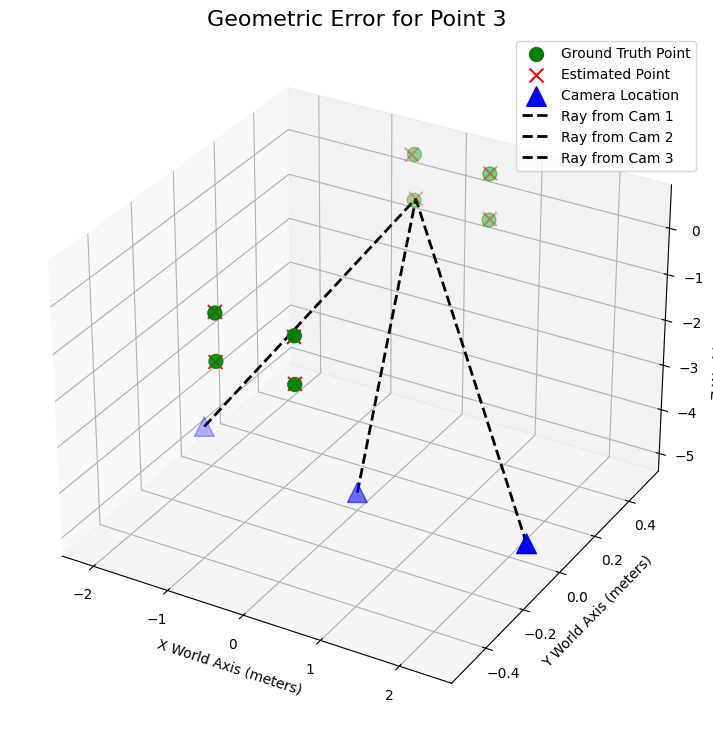

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

gt_pts = np.array(gt_3d_points)
est_pts = np.array(optimal_points) # We visualize the final 'optimal' points

all_R = [np.eye(3), R2, R3] # R1 is identity, R2 & R3 are from Task 1
all_t = [np.array([0,0,5]), t2, t3] # t1 is known, t2 & t3 are from Task 1

# --- Calculate Camera Centers in the World Coordinate System ---

camera_centers = []
for R, t in zip(all_R, all_t):
    # C = -R_transpose * t
    # It converts from the camera's recipe (R,t) to its actual world location (C).
    C = -R.T @ t
    camera_centers.append(C)

camera_centers = np.array(camera_centers)

# --- Create a 3D plot and add objects to it ---

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# --- Plot the Ground Truth (GT) and Estimated Points ---

# Plot the CORRECT cube corners as solid green circles
ax.scatter(gt_pts[:, 0], gt_pts[:, 1], gt_pts[:, 2], 
           c='green', marker='o', s=100, label='Ground Truth Point')

# Plot OUR ALGORITHM'S GUESS as red crosses
ax.scatter(est_pts[:, 0], est_pts[:, 1], est_pts[:, 2], 
           c='red', marker='x', s=100, label='Estimated Point')

# --- Plot the Cameras ---

# Plot the calculated camera centers as large blue triangles
ax.scatter(camera_centers[:, 0], camera_centers[:, 1], camera_centers[:, 2], 
           c='blue', marker='^', s=200, label='Camera Location')

# --- Plot the Rays (Lines of Sight) ---

# Get the observations 
point_index = 3
point_obs = obs_by_point[point_index]

# Loop through the cameras that saw the points
for obs in point_obs:
    cam_idx = obs[0] # The index of the camera (0, 1, or 2)
    
    # Get the coordinates for this specific camera and point
    camera_pos = camera_centers[cam_idx]
    point_pos = est_pts[point_index]
    
    # Draw a dashed line from the camera's location to the estimated point's location
    ax.plot([camera_pos[0], point_pos[0]], 
            [camera_pos[1], point_pos[1]], 
            [camera_pos[2], point_pos[2]], 
            'k--', linewidth=2, label=f'Ray from Cam {cam_idx+1}')

ax.set_title(f"Geometric Error for Point {point_index}", fontsize=16)
ax.set_xlabel('X World Axis (meters)')
ax.set_ylabel('Y World Axis (meters)')
ax.set_zlabel('Z World Axis (meters)')
ax.legend()
plt.show()

## TASK 3

In [23]:
# Camera Intrinsic Matrix
K = np.array([[800., 0., 320.], [0., 800., 240.], [0., 0., 1.]])

# 3D point to test on
X_true = np.array([0.5, 0.5, 0.5])  # A corner of the cube
X_homo = np.array([0.5, 0.5, 0.5, 1.0])

# Camera 1 (Fixed at [0,0,5])
R1 = np.eye(3)
t1 = np.array([0., 0., 5.])
P1 = K @ np.hstack((R1, t1.reshape(3,1)))

# Project, Add Noise, and Triangulate
def test_triangulation(P_cam1, P_cam3, name):

    # --- A. Project the 3D point into both cameras ---
    x1_perfect = P_cam1 @ X_homo
    u1, v1 = x1_perfect[0]/x1_perfect[2], x1_perfect[1]/x1_perfect[2]
    
    x3_perfect = P_cam3 @ X_homo
    u3, v3 = x3_perfect[0]/x3_perfect[2], x3_perfect[1]/x3_perfect[2]
    
    # Adding 2 pixels of noise to simulate reality 
    u1, v1 = u1 - 2.0, v1 - 2.0
    u3, v3 = u3 + 2.0, v3 + 2.0
    
    # Build Matrix A for DLT ---
    A = np.array([
        u1 * P_cam1[2,:] - P_cam1[0,:],
        v1 * P_cam1[2,:] - P_cam1[1,:],
        u3 * P_cam3[2,:] - P_cam3[0,:],
        v3 * P_cam3[2,:] - P_cam3[1,:]
    ])
    
    # Solve DLT via SVD ---
    U, S, Vt = np.linalg.svd(A)
    X_est_homo = Vt[-1]
    X_est = X_est_homo[:3] / X_est_homo[3] # Dehomogenize
    
    # Calculate 3D Error in millimeters ---
    error_mm = np.linalg.norm(X_est - X_true) * 1000
    
    print(f"Scenario: {name}")
    print(f"  3D Point Error:   {error_mm:.1f} mm\n")



# Run the Experiment
print("--- Degenerate Geometry Analysis ---\n")

# Scenario 1: Good Baseline (Cameras are 2.5 meters apart)
R3_good = np.eye(3)
t3_good = np.array([-2.5, 0.0, 5.0])
P3_good = K @ np.hstack((R3_good, t3_good.reshape(3,1)))

test_triangulation(P1, P3_good, "Good Geometry (2.5m Baseline)")


# Scenario 2: Degenerate Geometry (Cameras are 0.05 meters apart)
# They are "nearly coplanar" and coincident.
R3_bad = np.eye(3)
t3_bad = np.array([0.05, 0.0, 5.0]) 
P3_bad = K @ np.hstack((R3_bad, t3_bad.reshape(3,1)))

test_triangulation(P1, P3_bad, "Degenerate Geometry (0.05m Baseline)")

--- Degenerate Geometry Analysis ---

Scenario: Good Geometry (2.5m Baseline)
  3D Point Error:   62.4 mm

Scenario: Degenerate Geometry (0.05m Baseline)
  3D Point Error:   2901.6 mm

